# 🏞 Convolutional Neural Network

In this notebook, we'll walk through the steps required to train your own convolutional neural network (CNN) on the CIFAR dataset

In [1]:
import matplotlib.pyplot as plt


def sample_batch(dataset):
    batch = dataset.take(1).get_single_element()
    if isinstance(batch, tuple):
        batch = batch[0]
    return batch.numpy()


def display(
    images, n=10, size=(20, 3), cmap="gray_r", as_type="float32", save_to=None
):
    """
    Displays n random images from each one of the supplied arrays.
    """
    if images.max() > 1.0:
        images = images / 255.0
    elif images.min() < 0.0:
        images = (images + 1.0) / 2.0

    plt.figure(figsize=size)
    for i in range(n):
        _ = plt.subplot(1, n, i + 1)
        plt.imshow(images[i].astype(as_type), cmap=cmap)
        plt.axis("off")

    if save_to:
        plt.savefig(save_to)
        print(f"\nSaved to {save_to}")

    plt.show()


In [2]:
import numpy as np

from tensorflow.keras import layers, models, optimizers, utils, datasets
# from notebooks.utils import display

## 0. Parameters <a name="parameters"></a>

In [3]:
NUM_CLASSES = 10

## 1. Prepare the Data <a name="prepare"></a>

### Original (slow & skipped)

In [23]:
# (x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

In [24]:
# x_train = x_train.astype("float32") / 255.0
# x_test = x_test.astype("float32") / 255.0

# y_train = utils.to_categorical(y_train, NUM_CLASSES)
# y_test = utils.to_categorical(y_test, NUM_CLASSES)

### From Google Drive (works)

Problem: downloading the full dataset was very slow and resource wasting so decided to use Google drive as cache to save a ton of time and resources. The files are 100MB so not too bad. The code below was mostly generated by GPT-5.3-Codex with minor tweaks. 

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from tensorflow.keras import utils

# NUM_CLASSES = 10

# Update this folder to where your CSVs are in Drive
data_dir = "/content/drive/MyDrive/Colab Data"

train_df = pd.read_csv(f"{data_dir}/cifar10_train.csv")
test_df  = pd.read_csv(f"{data_dir}/cifar10_test.csv")


Mounted at /content/drive


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Columns: 3073 entries, pixel_0 to label
dtypes: int64(3073)
memory usage: 1.1 GB


In [6]:
train_df.describe()

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_3063,pixel_3064,pixel_3065,pixel_3066,pixel_3067,pixel_3068,pixel_3069,pixel_3070,pixel_3071,label
count,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000
mean,130.710740,130.14036,131.050440,131.568860,132.184700,132.851840,133.371540,133.890920,134.485040,134.93260,...,113.716260,113.735320,113.778520,113.813200,113.864120,113.877800,113.830580,113.906240,114.381860,4.50000
std,73.412873,72.44259,72.240546,72.016555,71.714551,71.537505,71.353558,71.281237,71.071698,71.03647,...,64.345623,64.431996,64.401897,64.502684,64.511269,64.738943,64.894603,65.212671,66.077526,2.87231
min,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,71.000000,71.00000,73.000000,73.000000,75.000000,75.000000,76.000000,76.750000,78.000000,78.00000,...,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,63.000000,2.00000
50%,128.000000,127.00000,129.000000,130.000000,130.000000,131.000000,132.000000,132.000000,133.000000,134.00000,...,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,4.50000
75%,189.000000,188.00000,188.000000,188.000000,189.000000,190.000000,190.000000,191.000000,191.000000,192.00000,...,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,158.000000,7.00000
max,255.000000,255.00000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.00000,...,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,9.00000


In [7]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 3073 entries, pixel_0 to label
dtypes: int64(3073)
memory usage: 234.5 MB


In [8]:

# Accept common label column names
possible_label_cols = ["label", "labels", "target", "y", "class"]
label_col = next((c for c in possible_label_cols if c in train_df.columns), train_df.columns[0])

y_train_raw = train_df[label_col].to_numpy()
y_test_raw  = test_df[label_col].to_numpy()

X_train = train_df.drop(columns=[label_col]).to_numpy(dtype=np.float32)
X_test  = test_df.drop(columns=[label_col]).to_numpy(dtype=np.float32)

# Scale to [0,1]
if X_train.max() > 1.0:
    X_train /= 255.0
    X_test  /= 255.0

# CIFAR-10 flattened is 3072 = 32*32*3
# Common CSV layout is channel-first blocks: R(1024), G(1024), B(1024)
x_train = X_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
x_test  = X_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

y_train = utils.to_categorical(y_train_raw, NUM_CLASSES)
y_test  = utils.to_categorical(y_test_raw, NUM_CLASSES)

print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_test :", x_test.shape, "y_test :", y_test.shape)

x_train: (50000, 32, 32, 3) y_train: (50000, 10)
x_test : (10000, 32, 32, 3) y_test : (10000, 10)


In [9]:
import tensorflow as tf
# tf.keras.backend.clear_session()

# Ensure clean dtypes
x_train = x_train.astype("float32")
x_test = x_test.astype("float32")
y_train = y_train.astype("float32")
y_test = y_test.astype("float32")

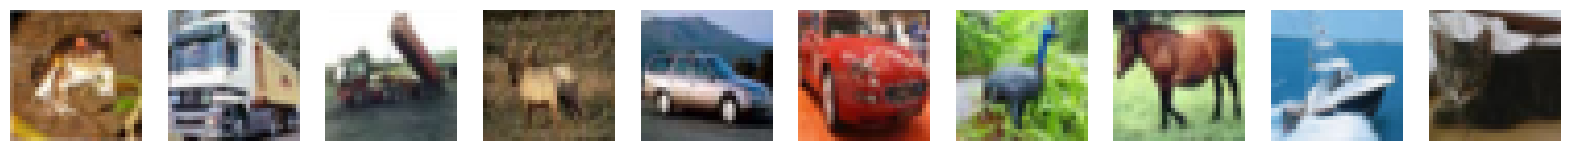

[[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]


In [10]:
display(x_train[:10])
print(y_train[:10])

## 2. Build the model <a name="build"></a>

In [11]:
input_layer = layers.Input((32, 32, 3))

x = layers.Conv2D(filters=32, kernel_size=3, strides=1, padding="same")(
    input_layer
)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

x = layers.Conv2D(filters=32, kernel_size=3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

x = layers.Conv2D(filters=64, kernel_size=3, strides=1, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

x = layers.Conv2D(filters=64, kernel_size=3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

x = layers.Flatten()(x)

x = layers.Dense(128)(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)
x = layers.Dropout(rate=0.5)(x)

x = layers.Dense(NUM_CLASSES)(x)
output_layer = layers.Activation("softmax")(x)

model = models.Model(input_layer, output_layer)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 592,554 (2.26 MB)

 Trainable params: 591,914 (2.26 MB)

 Non-trainable params: 640 (2.50 KB)

## 3. Train the model <a name="train"></a>

In [12]:
opt = optimizers.Adam(learning_rate=0.0005)
model.compile(
    loss="categorical_crossentropy", optimizer=opt, metrics=["accuracy"]
)

In [13]:
model.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=10,
    shuffle=True,
    validation_data=(x_test, y_test),
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - accuracy: 0.4495 - loss: 1.5628 - val_accuracy: 0.5071 - val_loss: 1.3782
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5873 - loss: 1.1677 - val_accuracy: 0.6266 - val_loss: 1.0596
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6442 - loss: 1.0161 - val_accuracy: 0.6434 - val_loss: 1.0135
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6761 - loss: 0.9271 - val_accuracy: 0.6683 - val_loss: 0.9386
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6981 - loss: 0.8656 - val_accuracy: 0.6452 - val_loss: 1.0284
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7168 - loss: 0.8107 - val_accuracy: 0.6951 - val_loss: 0.8776
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7342 - loss: 0.7608 - val_accuracy: 0.7172 - val_loss: 0.8235
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7400 - loss: 0.7412 -

## 4. Evaluation <a name="evaluate"></a>

In [14]:
model.evaluate(x_test, y_test, batch_size=1000)

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7081 - loss: 0.8445


[0.8444613218307495, 0.7081000208854675]

In [15]:
CLASSES = np.array(
    [
        "airplane",
        "automobile",
        "bird",
        "cat",
        "deer",
        "dog",
        "frog",
        "horse",
        "ship",
        "truck",
    ]
)

preds = model.predict(x_test)
preds_single = CLASSES[np.argmax(preds, axis=-1)]
actual_single = CLASSES[np.argmax(y_test, axis=-1)]

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


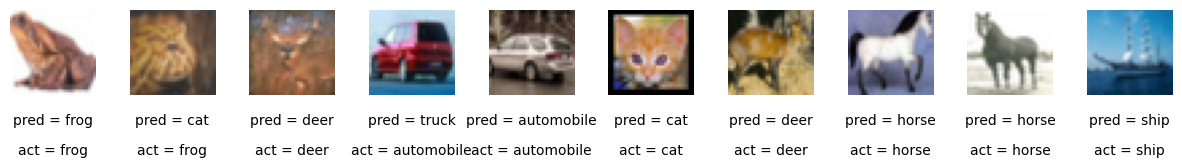

In [16]:
import matplotlib.pyplot as plt

n_to_show = 10
indices = np.random.choice(range(len(x_test)), n_to_show)

fig = plt.figure(figsize=(15, 3))
fig.subplots_adjust(hspace=0.4, wspace=0.4)

for i, idx in enumerate(indices):
    img = x_test[idx]
    ax = fig.add_subplot(1, n_to_show, i + 1)
    ax.axis("off")
    ax.text(
        0.5,
        -0.35,
        "pred = " + str(preds_single[idx]),
        fontsize=10,
        ha="center",
        transform=ax.transAxes,
    )
    ax.text(
        0.5,
        -0.7,
        "act = " + str(actual_single[idx]),
        fontsize=10,
        ha="center",
        transform=ax.transAxes,
    )
    ax.imshow(img)

# Stride Comparison

In [17]:
import tensorflow as tf
import pandas as pd
from tensorflow.keras import layers, models, optimizers

# Optional: make runs more comparable
SEED = 42
tf.keras.utils.set_random_seed(SEED)

def build_cnn(stride_downsample=2):
    input_layer = layers.Input((32, 32, 3))

    x = layers.Conv2D(filters=32, kernel_size=3, strides=1, padding="same")(input_layer)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    # first downsampling conv
    x = layers.Conv2D(filters=32, kernel_size=3, strides=stride_downsample, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2D(filters=64, kernel_size=3, strides=1, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    # second downsampling conv
    x = layers.Conv2D(filters=64, kernel_size=3, strides=stride_downsample, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(rate=0.5)(x)

    x = layers.Dense(NUM_CLASSES)(x)
    output_layer = layers.Activation("softmax")(x)

    model = models.Model(input_layer, output_layer)
    opt = optimizers.Adam(learning_rate=0.0005)
    model.compile(loss="categorical_crossentropy", optimizer=opt, metrics=["accuracy"])
    return model

strides_to_try = [1, 2, 3]  # example sweep
results = []
histories = {}
trained_models = {}

for s in strides_to_try:
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)

    model_s = build_cnn(stride_downsample=s)

    history = model_s.fit(
        x_train,
        y_train,
        batch_size=32,
        epochs=10,
        shuffle=True,
        validation_data=(x_test, y_test),
        verbose=1
    )

    test_loss, test_acc = model_s.evaluate(x_test, y_test, batch_size=1000, verbose=0)

    results.append({
        "stride": s,
        "test_loss": float(test_loss),
        "test_acc": float(test_acc),
        "best_val_acc": float(max(history.history["val_accuracy"])),
        "final_val_acc": float(history.history["val_accuracy"][-1]),
    })

    histories[s] = history.history
    trained_models[s] = model_s

results_df = pd.DataFrame(results).sort_values("test_acc", ascending=False)
results_df

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - accuracy: 0.5003 - loss: 1.4346 - val_accuracy: 0.5714 - val_loss: 1.3138
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6399 - loss: 1.0333 - val_accuracy: 0.6484 - val_loss: 1.0161
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6839 - loss: 0.9068 - val_accuracy: 0.6577 - val_loss: 0.9979
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7179 - loss: 0.8064 - val_accuracy: 0.6648 - val_loss: 0.9855
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7545 - loss: 0.7073 - val_accuracy: 0.6427 - val_loss: 1.0920
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7854 - loss: 0.6154 - val_accuracy: 0.6444 - val_loss: 1.1169
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8126 - loss: 0.5343 - val_accuracy: 0.6751 - val_loss: 1.0265
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8375 - loss: 0.4645 -

,stride,test_loss,test_acc,best_val_acc,final_val_acc
1,2,0.969366,0.6927,0.7050,0.6927
2,3,0.991364,0.6708,0.6708,0.6708
0,1,1.263893,0.6586,0.6751,0.6586


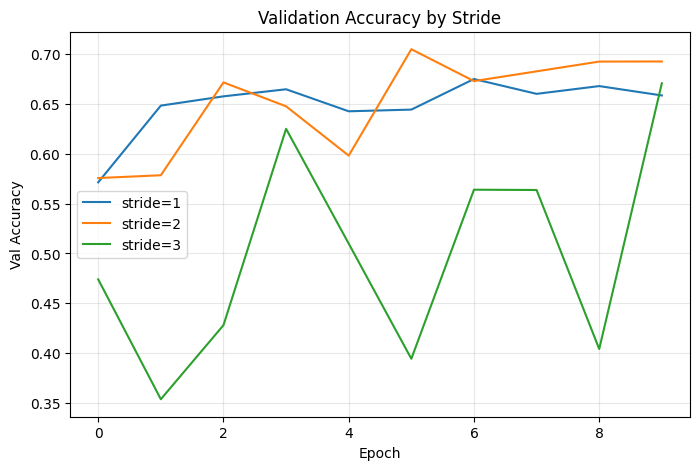

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
for s in strides_to_try:
    plt.plot(histories[s]["val_accuracy"], label=f"stride={s}")
plt.title("Validation Accuracy by Stride")
plt.xlabel("Epoch")
plt.ylabel("Val Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()